A comparative NLP study that benchmarks multiple text vectorization techniques and machine learning classifiers on the task of distinguishing questions from declarative sentences.

In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import tensorflow as tf
data=pd.read_csv("/content/1646977175-5e748a2d5fc288e9f69c5f86.csv")
nltk.download('stopwords')
nltk.download('punkt')

True
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
def clean_sentence(sentence):
    sentence = re.sub(r'<[^>]+>', '', sentence)
    sentence = re.sub(r'[^a-zA-Z\s]', '', sentence)
    sentence = sentence.lower()
    tokens = word_tokenize(sentence)
    return " ".join(tokens)
data['cleaned_sentence'] = data['sentence'].apply(clean_sentence)
data.drop(columns=["sentence","Unnamed: 0"], inplace=True)
label_map = {'question': 1, 'sentence': 0}
data['label'] = data['label'].map(label_map)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


TF-IDF vectorization using different models

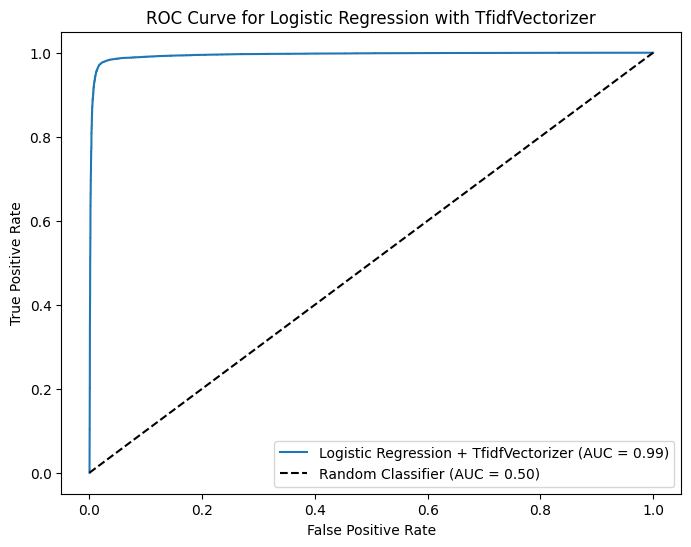

Logistic Regression Accuracy: 0.9770320275615669
Naive Bayes Accuracy: 0.8681680915316234
Random Forest Accuracy: 0.9646973756964825
Decision Tree Accuracy: 0.9721407000978266


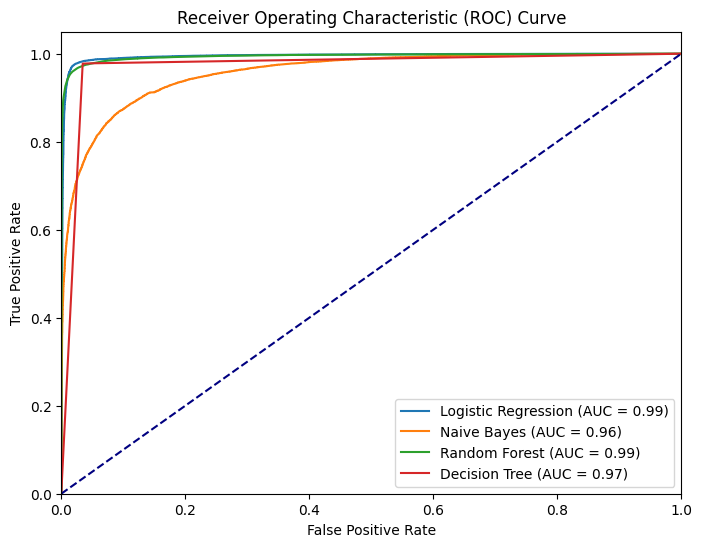

In [ ]:
data =pd.read_csv("/content/1646977175-5e748a2d5fc288e9f69c5f86.csv")
data['cleaned_sentence'] = data['sentence'].apply(clean_sentence)
# Splitting the data into train and test sets

X = data['cleaned_sentence']

y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)
label_map = {'question': 1, 'sentence': 0}
y_train = y_train.map(label_map)
y_test = y_test.map(label_map)
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)
model = LogisticRegression()
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression + TfidfVectorizer (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with TfidfVectorizer')
plt.legend(loc='lower right')
plt.show()
# Model Training
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
predictions_lr = logistic_regression.predict(X_test)
accuracy_lr = accuracy_score(y_test, predictions_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)
predictions_nb = naive_bayes.predict(X_test)
accuracy_nb = accuracy_score(y_test, predictions_nb)
print("Naive Bayes Accuracy:", accuracy_nb)
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
predictions_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, predictions_rf)
print("Random Forest Accuracy:", accuracy_rf)
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
predictions_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, predictions_dt)
print("Decision Tree Accuracy:", accuracy_dt)
classifiers = {
    "Logistic Regression": logistic_regression,
    "Naive Bayes": naive_bayes,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree
}
plt.figure(figsize=(8, 6))
for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(X_test)[:, 1]
    else:
        probas = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf_vectorizer.fit_transform(data['clean_sentence'])
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier


# Split data for TF-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(tfidf_matrix, data['label'], test_size=0.2, random_state=42)
label_map = {'question': 1, 'sentence': 0}
y_train_tfidf = y_train_tfidf.map(label_map)
y_test_tfidf = y_test_tfidf.map(label_map)

# Define and train models for TF-IDF
log_reg_model_tfidf = LogisticRegression()
log_reg_model_tfidf.fit(X_train_tfidf, y_train_tfidf)

nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train_tfidf, y_train_tfidf)

dt_model_tfidf = DecisionTreeClassifier()
dt_model_tfidf.fit(X_train_tfidf, y_train_tfidf)

rf_model_tfidf = RandomForestClassifier()
rf_model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluate models for TF-IDF
models_tfidf = [log_reg_model_tfidf, nb_model_tfidf, rf_model_tfidf, dt_model_tfidf]
model_names_tfidf = ['Logistic Regression (TF-IDF)', 'Naive Bayes (TF-IDF)', 'Random Forest (TF-IDF)', 'Decision Tree (TF-IDF)']

for i, model in enumerate(models_tfidf):
    y_pred_tfidf = model.predict(X_test_tfidf)
    accuracy = np.mean(y_pred_tfidf == y_test_tfidf)
    print(f"Accuracy for {model_names_tfidf[i]}: {accuracy:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test_tfidf, y_pred_tfidf)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Sentence', 'Question'], yticklabels=['Sentence', 'Question'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_names_tfidf[i]}')
    plt.show()

    # ROC Curve
    y_pred_proba_tfidf = model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_tfidf, y_pred_proba_tfidf)
    auc_score = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{model_names_tfidf[i]} (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_names_tfidf[i]}')
    plt.legend()
    plt.show()

Sentence embedding

In [ ]:
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
# Sentence Embeddings (Doc2Vec)
tagged_data = [TaggedDocument(words=word_tokenize(sentence), tags=[str(i)]) for i, sentence in enumerate(data['clean_sentence'])]
doc2vec_model = Doc2Vec(tagged_data, vector_size=100, window=2, min_count=1, workers=4)
# Convert tagged data to vectors
doc2vec_vectors = [doc2vec_model.infer_vector(tagged_data[i][0]) for i in range(len(tagged_data))]
doc2vec_matrix = np.array(doc2vec_vectors)

# Split data for Doc2Vec
X_train_doc2vec, X_test_doc2vec, y_train_doc2vec, y_test_doc2vec = train_test_split(doc2vec_matrix, data['label'], test_size=0.2, random_state=42)

# Define and train models for Doc2Vec
log_reg_model_doc2vec = LogisticRegression()
log_reg_model_doc2vec.fit(X_train_doc2vec, y_train_doc2vec)

rf_model_doc2vec = RandomForestClassifier()
rf_model_doc2vec.fit(X_train_doc2vec, y_train_doc2vec)

svm_model_doc2vec = SVC(probability=True)
svm_model_doc2vec.fit(X_train_doc2vec, y_train_doc2vec)

dt_model_tfidf = DecisionTreeClassifier()
dt_model_tfidf.fit(X_train_doc2vec, y_train_doc2vec)

# Evaluate models for Doc2Vec
models_doc2vec = [log_reg_model_doc2vec, rf_model_doc2vec, svm_model_doc2vec, gb_model_doc2vec]
model_names_doc2vec = ['Logistic Regression (Doc2Vec)', 'Random Forest (Doc2Vec)', 'SVM (Doc2Vec)', 'DecisionTreeClassifier (Doc2Vec)']

plt.figure(figsize=(10, 6))
for i, model in enumerate(models_doc2vec):
    y_pred_proba_doc2vec = model.predict_proba(X_test_doc2vec)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_doc2vec, y_pred_proba_doc2vec)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_names_doc2vec[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Doc2Vec)')
plt.legend()
plt.show()


word embedding(different models)

In [ ]:
import pandas as pd

# Load data
data = pd.read_csv('/content/1646977175-5e748a2d5fc288e9f69c5f86.csv')

# Check the columns of the DataFrame
print(data.columns)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import numpy as np
from sklearn.svm import SVC
from keras.layers import LSTM, Dense, Embedding, SpatialDropout1D

sentences = [word_tokenize(sentence) for sentence in data['sentence']]
word2vec_model = Word2Vec(sentences, min_count=1)
def sentence_to_vec_word2vec(sentence, model):
    vector_size = model.vector_size
    words = sentence.split()
    sentence_vec = []
    for word in words:
        if word in model.wv:
            sentence_vec.append(model.wv[word])
    if sentence_vec:
        return np.mean(sentence_vec, axis=0)
    else:
        return np.zeros(vector_size)
X_word2vec = []
y_encoded = []
for sentence, label in zip(data['sentence'], data['label']):
    vec = sentence_to_vec_word2vec(sentence, word2vec_model)
    X_word2vec.append(vec)
    y_encoded.append(label)
X_word2vec = np.array(X_word2vec)
y_encoded = np.array(y_encoded)
X_train, X_test, y_train, y_test = train_test_split(X_word2vec, y_encoded, test_size=0.2, random_state=42)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.fit_transform(y_test)
model = LogisticRegression()
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression + Word2vec (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with Word2vec')
plt.legend(loc='lower right')
plt.show()
print("Shape of X:", X.shape)

# Model Building and Evaluation
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'LSTM': Sequential([
        Embedding(input_dim=X.shape[1], output_dim=100, input_length=X.shape[1]),
        SpatialDropout1D(0.2),
        LSTM(100, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
}

plt.figure(figsize=(12, 10))

for name, model in models.items():
    if name == 'LSTM': Sequential([
    Embedding(input_dim=X.shape[1], output_dim=100, input_length=X.shape[1]),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')])

    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Calculate confusion matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f'Confusion Matrix for {name}:')
    print(cm)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy for {name}: {accuracy:.2f}')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

LSA with different models    (Naive Bayes is not used in this vectorization as it cant take negative values)

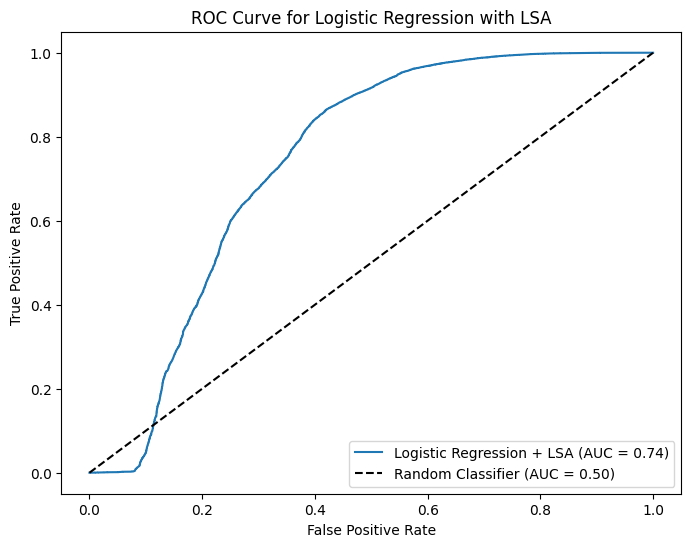

Logistic Regression Accuracy: 0.73844158053677


In [ ]:
data =pd.read_csv("/content/1646977175-5e748a2d5fc288e9f69c5f86.csv")
data['cleaned_sentence'] = data['sentence'].apply(clean_sentence)
# Splitting the data into train and test sets

X = data['cleaned_sentence']

y = data['label']

count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(X)
from sklearn.decomposition import TruncatedSVD
lsa_model = TruncatedSVD()
X_lsa = lsa_model.fit_transform(X_count)

X_train, X_test, y_train, y_test = train_test_split(X_lsa, y, test_size=0.2, random_state=23)
label_map = {'question': 1, 'sentence': 0}
y_train = y_train.map(label_map)
y_test = y_test.map(label_map)


model = LogisticRegression()
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression + LSA (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with LSA')
plt.legend(loc='lower right')
plt.show()
# Model Training
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
predictions_lr = logistic_regression.predict(X_test)
accuracy_lr = accuracy_score(y_test, predictions_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
from sklearn.svm import SVC
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
predictions_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, predictions_svm)
print("SVM accuracy:", accuracy_svm)
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
predictions_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, predictions_rf)
print("Random Forest Accuracy:", accuracy_rf)
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
predictions_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, predictions_dt)
print("Decision Tree Accuracy:", accuracy_dt)
classifiers = {
    "Logistic Regression": logistic_regression,
    "SVM": svm_model,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree
}
plt.figure(figsize=(8, 6))
for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(X_test)[:, 1]
    else:
        probas = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

LDA with different models

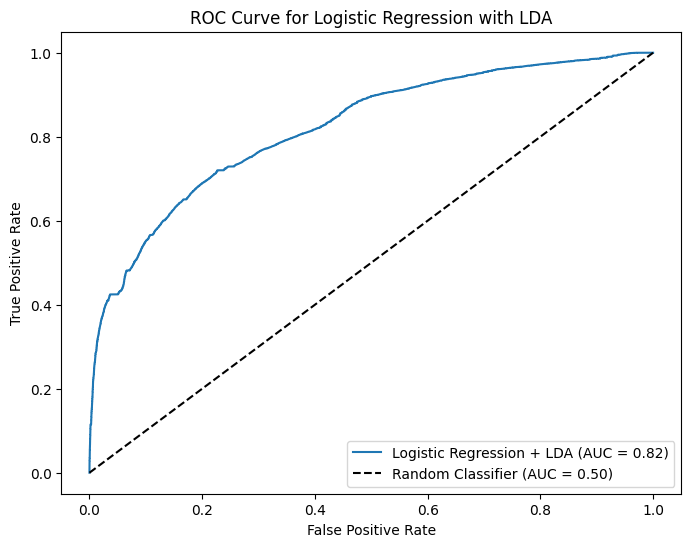

Confusion Matrix:
[[16148  4662]
 [ 7533 18679]]

Accuracy: 0.7406533112160265
Logistic Regression Accuracy: 0.7406533112160265
Naive Bayes Accuracy: 0.7030538896686658
Random Forest Accuracy: 0.8988133214240143
Decision Tree Accuracy: 0.853026243035175


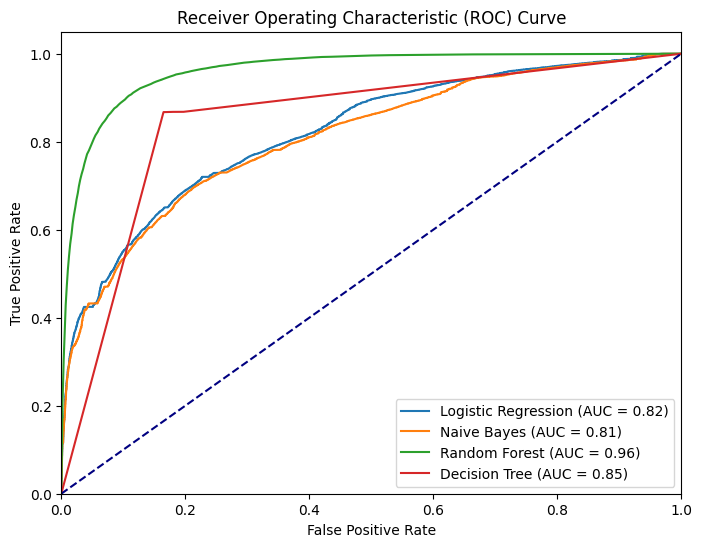

In [ ]:
X = data['cleaned_sentence']
y = data['label']
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(X)
lda_model = LatentDirichletAllocation()
X_lda = lda_model.fit_transform(X_count)
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=23)
label_map = {'question': 1, 'sentence': 0}
y_train = y_train.map(label_map)
y_test = y_test.map(label_map)
model = LogisticRegression()
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression + LDA (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with LDA')
plt.legend(loc='lower right')
plt.show()

# Predict classes for the test set
y_pred = model.predict(X_test)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("\nAccuracy:", accuracy)
# Model Training
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
predictions_lr = logistic_regression.predict(X_test)
accuracy_lr = accuracy_score(y_test, predictions_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)
predictions_nb = naive_bayes.predict(X_test)
accuracy_nb = accuracy_score(y_test, predictions_nb)
print("Naive Bayes Accuracy:", accuracy_nb)
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
predictions_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, predictions_rf)
print("Random Forest Accuracy:", accuracy_rf)
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
predictions_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, predictions_dt)
print("Decision Tree Accuracy:", accuracy_dt)
classifiers = {
    "Logistic Regression": logistic_regression,
    "Naive Bayes": naive_bayes,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree
}
plt.figure(figsize=(8, 6))
for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(X_test)[:, 1]
    else:
        probas = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


API

In [ ]:
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    text = data['text']
    clean_text = clean_text(text)
    vectorized_text = tfidf_vectorizer.transform([clean_text])
    prediction = log_reg_model.predict(vectorized_text)[0]
    return jsonify({'prediction': prediction})

if __name__ == '__main__':
    app.run(debug=True, port=5000)
